# Campus Placement — ML Project
# Loading & Initial Analysis 
**AI Module | Assessment 1 | LIS MASc | 2025-26 | 25000148737**

This notebook trains a supervised machine learning model to classify whether a graduate student will receive a job placement offer, based on academic and personal features. It documents data loading, exploratory analysis, preprocessing, model training, evaluation, and bias reflection.

**Dataset:** [Campus Recruitment Dataset — Kaggle](https://www.kaggle.com/datasets/benroshan/factors-affecting-campus-placement)  
**Target variable:** `status` (Placed / Not Placed)  
**Type:** Binary classification

Note: This is one of 5 total notebooks. Please check the other notebooks for further project investigations. 

AI Disclosure: The free tier of Claude Sonnet 4.6 was used for code generation support in developing this LLM classification model. All notebook markdown, final evaluation, and code execution/debugging are my own. No other AI was used.

---
## 1. Environment setup
Importing of all the libraries used throughout this notebook.

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load the dataset

In [2]:
# Load CSV — data path used to update the path to easily match the /data folder
DATA_PATH = '../data/Placement_Data_Full_Class.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded: 215 rows, 15 columns


---
## 3. First look at the data

In [3]:
# First 5 rows
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.00,Mkt&HR,58.80,Placed,270000.00
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.50,Mkt&Fin,66.28,Placed,200000.00
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.00,Mkt&Fin,57.80,Placed,250000.00
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.80,Mkt&Fin,55.50,Placed,425000.00


In [4]:
# Column names, dtypes, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [5]:
# Summary statistics for numeric columns
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.00,215.00,215.00,215.00,215.00,215.00,148.00
mean,108.00,67.30,66.33,66.37,72.10,62.28,288655.41
std,62.21,10.83,10.90,7.36,13.28,5.83,93457.45
min,1.00,40.89,37.00,50.00,50.00,51.21,200000.00
25%,54.50,60.60,60.90,61.00,60.00,57.95,240000.00
50%,108.00,67.00,65.00,66.00,71.00,62.00,265000.00
75%,161.50,75.70,73.00,72.00,83.50,66.25,300000.00
max,215.00,89.40,97.70,91.00,98.00,77.89,940000.00


In [6]:
# Summary statistics for categorical columns
df.describe(include='object')

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
count,215,215,215,215,215,215,215,215
unique,2,2,2,3,3,2,2,2
top,M,Central,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
freq,139,116,131,113,145,141,120,148


---
## 4. Existing & missing value audit

In [7]:
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()

# Classify each column as numeric or categorical
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numeric columns  ({len(num_cols)}): {num_cols}')
print(f'Categorical cols ({len(cat_cols)}): {cat_cols}')

Shape: 215 rows x 15 columns

Numeric columns  (7): ['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
Categorical cols (8): ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing count': missing,
    'Missing %': missing_pct
}).query('`Missing count` > 0')

if missing_report.empty:
    print('No missing values found.')
else:
    print(missing_report)

        Missing count  Missing %
salary             67      31.16


The `salary` column has  missing values for students who were not placed and this is expected, not an error. I will drop `salary` before modelling since it is a consequence of placement, not a predictor of it.

---
## 5. Target variable: class balance

Before modelling, I checked whether our target classes are balanced. A heavily imbalanced dataset (e.g. 95% Placed, 5% Not Placed) would require special handling and would make raw accuracy a misleading metric.

            Count  Percentage %
status                         
Placed        148         68.80
Not Placed     67         31.20


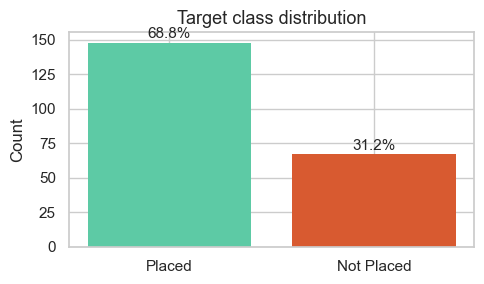

In [9]:
TARGET = 'status'

counts = df[TARGET].value_counts()
pcts   = df[TARGET].value_counts(normalize=True).mul(100).round(1)

print(pd.DataFrame({'Count': counts, 'Percentage %': pcts}))

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(counts.index, counts.values, color=['#5DCAA5', '#D85A30'], edgecolor='none')

# Annotate each bar with its percentage
for bar, pct in zip(bars, pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{pct}%', ha='center', va='bottom', fontsize=11
    )

ax.set_title('Target class distribution', fontsize=13)
ax.set_ylabel('Count')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Imbalance warning
ratio = counts.max() / counts.min()
if ratio > 2:
    print(f'WARNING: Class imbalance ratio {ratio:.1f}:1 — consider stratified split and weighted F1 over accuracy.')
else:
    print(f'Class ratio {ratio:.1f}:1 — reasonably balanced, accuracy is a usable metric.')

Class distribution:
            Count  Percentage %
status                         
Placed        148         68.80
Not Placed     67         31.20


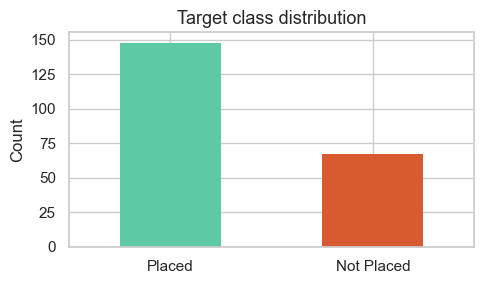

In [10]:
TARGET = 'status'

class_counts = df[TARGET].value_counts()
class_pcts   = df[TARGET].value_counts(normalize=True).mul(100).round(1)

print('Class distribution:')
print(pd.DataFrame({'Count': class_counts, 'Percentage %': class_pcts}))

fig, ax = plt.subplots(figsize=(5, 3))
class_counts.plot(kind='bar', ax=ax, color=['#5DCAA5', '#D85A30'], edgecolor='none')
ax.set_title('Target class distribution', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## 6. Exploratory data analysis (EDA)

I visualised the relationship between key features and placement outcome. This informs both modelling decisions and the bias analysis later.

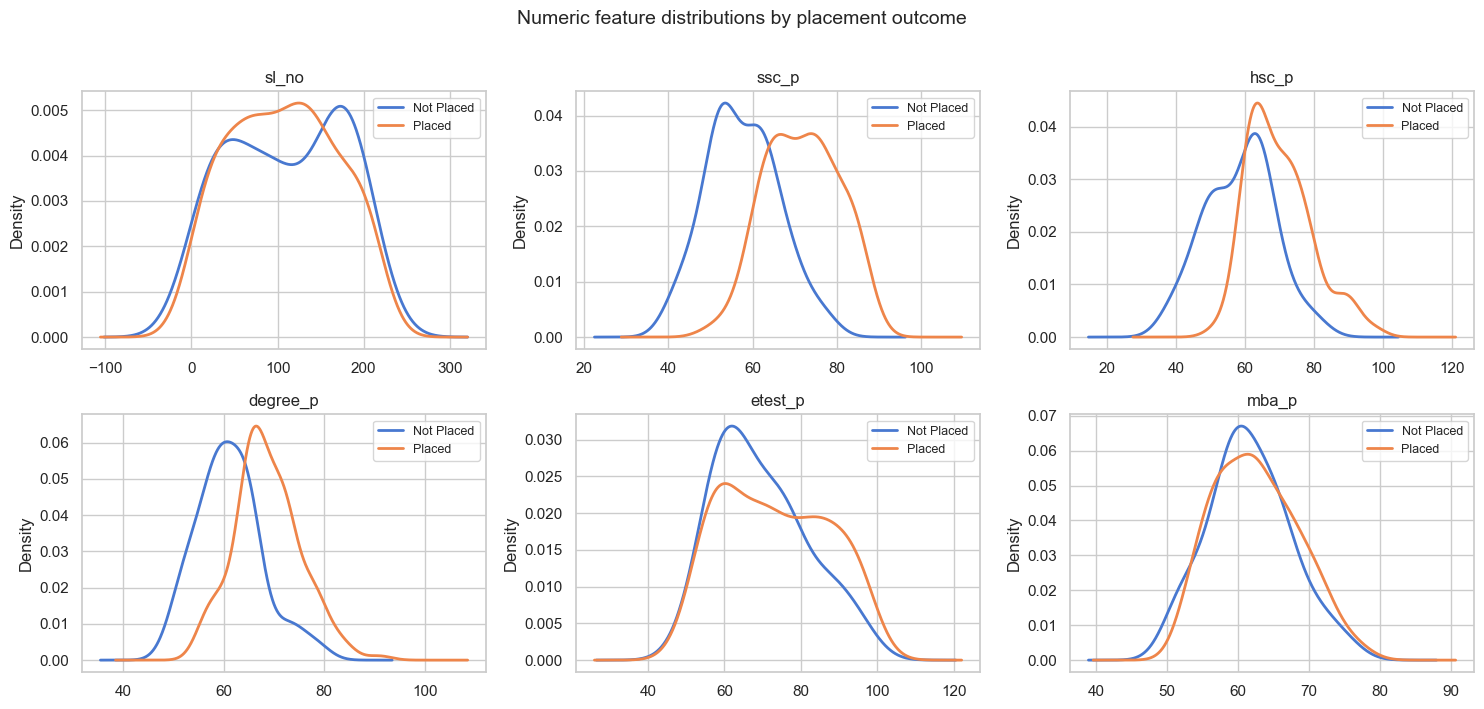

In [11]:
# Drop the salary data 
plot_num_cols = [c for c in num_cols if c != 'salary']

n = len(plot_num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(plot_num_cols):
    # Histogram with KDE overlay, split by target
    for label, grp in df.groupby(TARGET):
        grp[col].plot(kind='kde', ax=axes[i], label=label, linewidth=2)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=9)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric feature distributions by placement outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

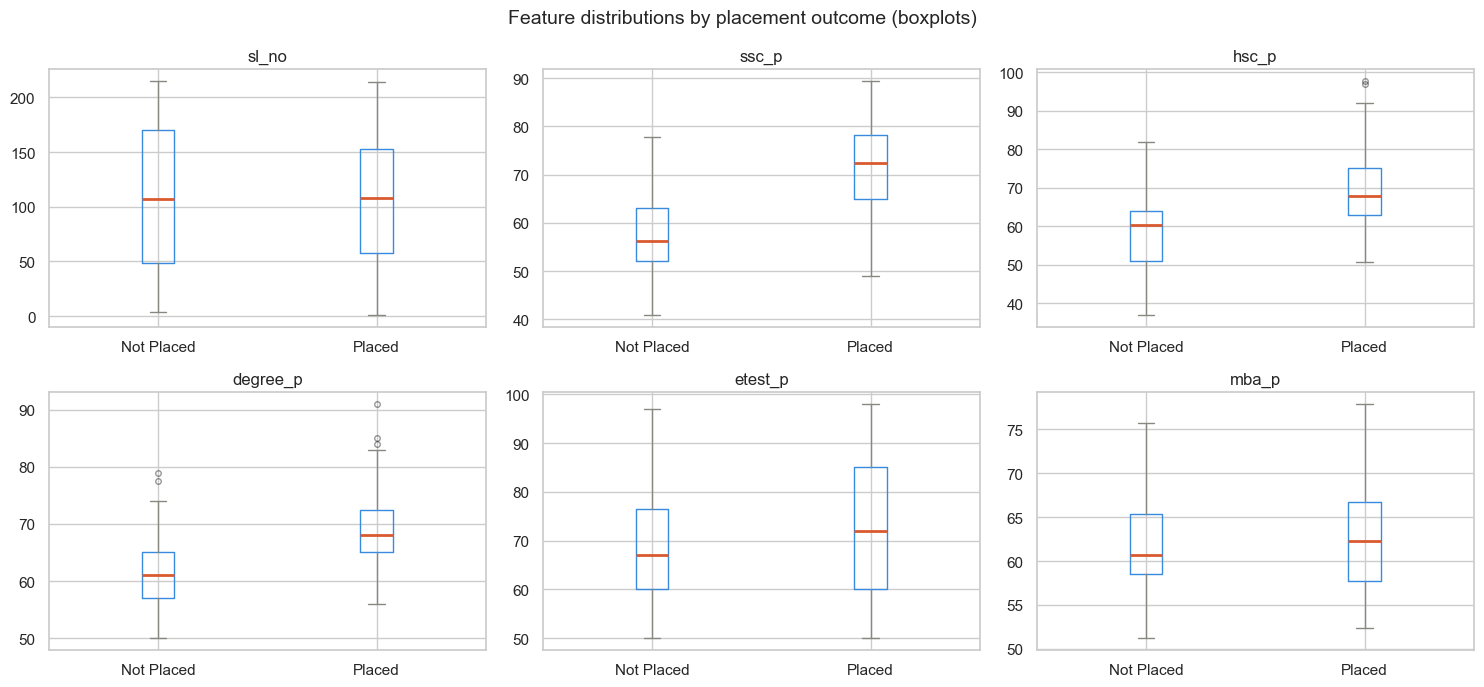

In [12]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(plot_num_cols):
    df.boxplot(
        column=col, by=TARGET, ax=axes[i],
        boxprops=dict(color='#378ADD'),
        medianprops=dict(color='#D85A30', linewidth=2),
        whiskerprops=dict(color='#888780'),
        capprops=dict(color='#888780'),
        flierprops=dict(marker='o', color='#D85A30', alpha=0.4, markersize=4)
    )
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature distributions by placement outcome (boxplots)', fontsize=14)
plt.tight_layout()
plt.show()

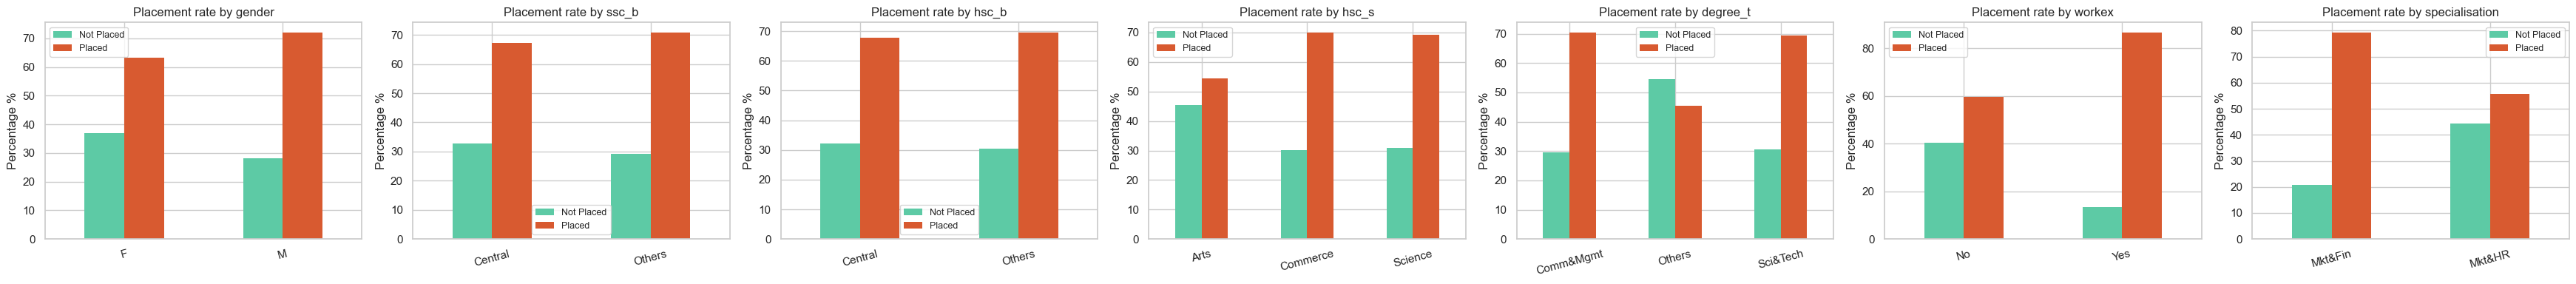

In [13]:
# Exclude the target itself from the list
plot_cat_cols = [c for c in cat_cols if c != TARGET]

n_cat = len(plot_cat_cols)
fig, axes = plt.subplots(1, n_cat, figsize=(5 * n_cat, 4))
if n_cat == 1:
    axes = [axes]

for i, col in enumerate(plot_cat_cols):
    ct = df.groupby(col)[TARGET].value_counts(normalize=True).mul(100).unstack().fillna(0)
    ct.plot(kind='bar', ax=axes[i], color=['#5DCAA5', '#D85A30'], edgecolor='none')
    axes[i].set_title(f'Placement rate by {col}', fontsize=12)
    axes[i].set_ylabel('Percentage %')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(title='', fontsize=9)

plt.tight_layout()
plt.show()

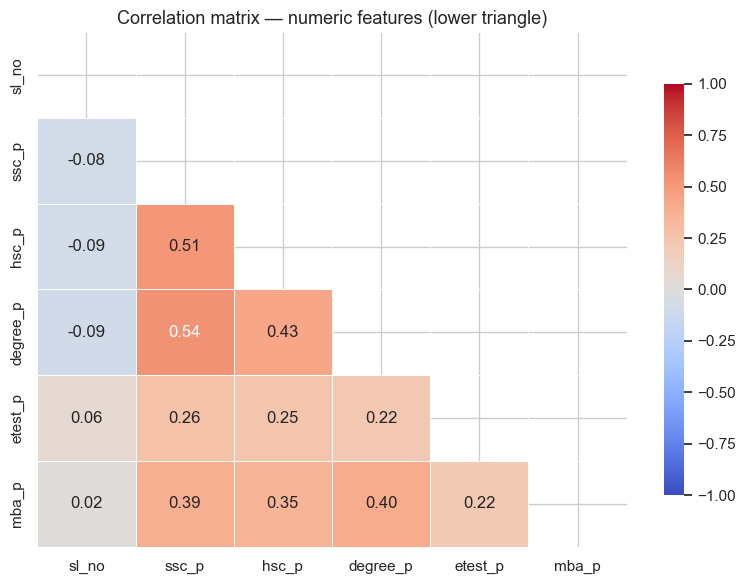

No feature pairs with |r| > 0.7 detected.


In [14]:
corr_cols = [c for c in num_cols if c != 'salary']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation matrix — numeric features (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

# Flag high correlations automatically
high_corr = [
    (r, c, corr_matrix.loc[r, c])
    for r in corr_matrix.index
    for c in corr_matrix.columns
    if r < c and abs(corr_matrix.loc[r, c]) > 0.7
]
if high_corr:
    print('High correlations (|r| > 0.7):')
    for r, c, v in high_corr:
        print(f'  {r} — {c}: {v:.2f}')
else:
    print('No feature pairs with |r| > 0.7 detected.')

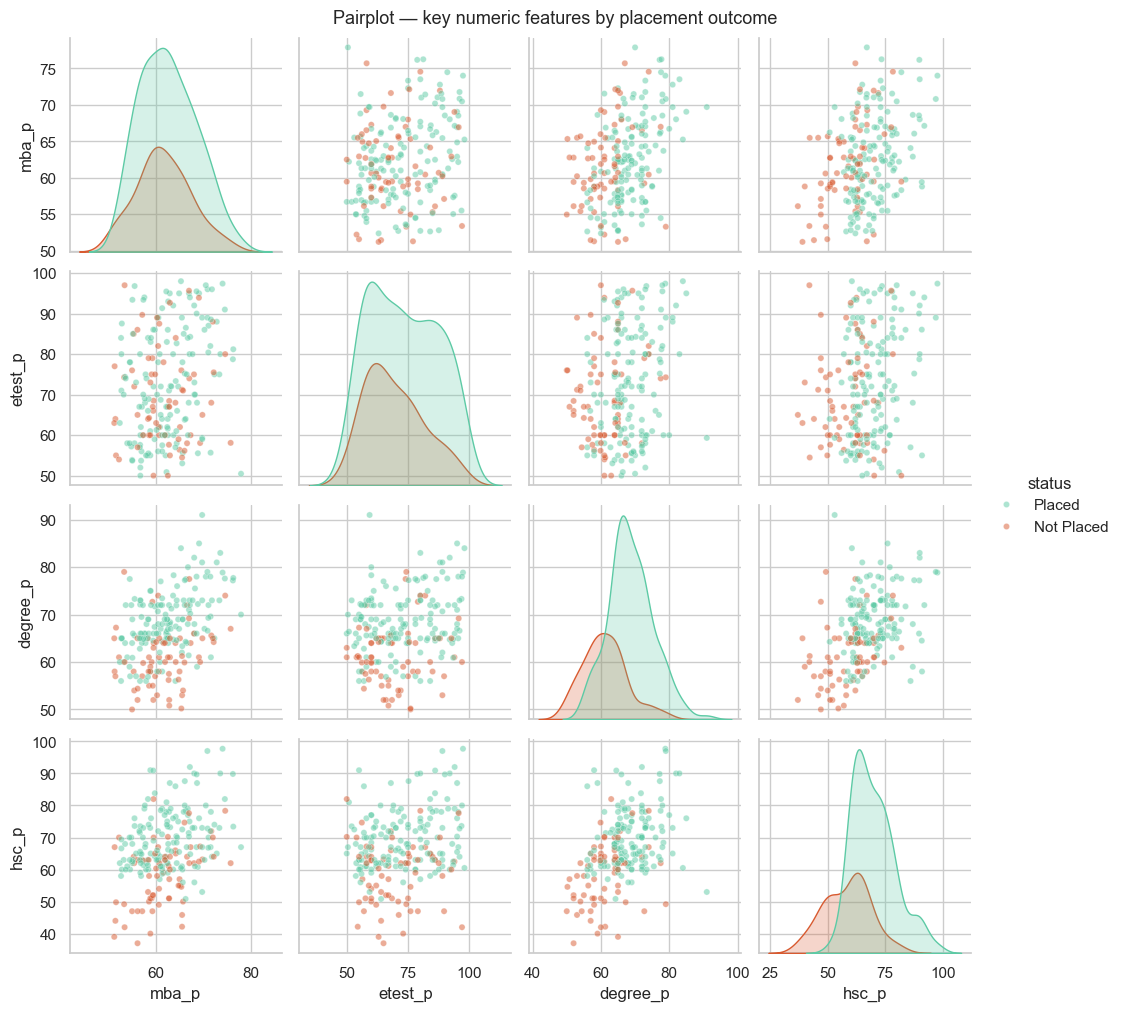

In [15]:
# Select 4 features most likely to discriminate 
pairplot_cols = ['mba_p', 'etest_p', 'degree_p', 'hsc_p', TARGET]
pairplot_df = df[pairplot_cols].dropna()

g = sns.pairplot(
    pairplot_df, hue=TARGET,
    palette={'Placed': '#5DCAA5', 'Not Placed': '#D85A30'},
    diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20}
)
g.fig.suptitle('Pairplot — key numeric features by placement outcome', y=1.01, fontsize=13)
plt.show()

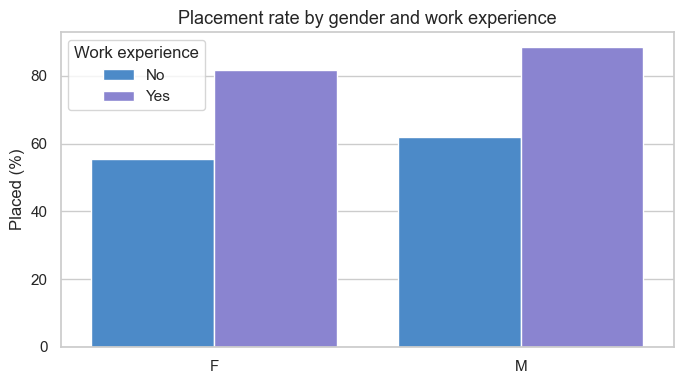

In [16]:
# Placement rate by gender AND work experience 
bias_df = df.groupby(['gender', 'workex'])[TARGET].value_counts(normalize=True)\
             .mul(100).rename('Placement %').reset_index()
bias_placed = bias_df[bias_df[TARGET] == 'Placed']

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=bias_placed, x='gender', y='Placement %',
    hue='workex', palette=['#378ADD', '#7F77DD'], ax=ax
)
ax.set_title('Placement rate by gender and work experience', fontsize=13)
ax.set_ylabel('Placed (%)')
ax.set_xlabel('')
ax.legend(title='Work experience')
plt.tight_layout()
plt.show()

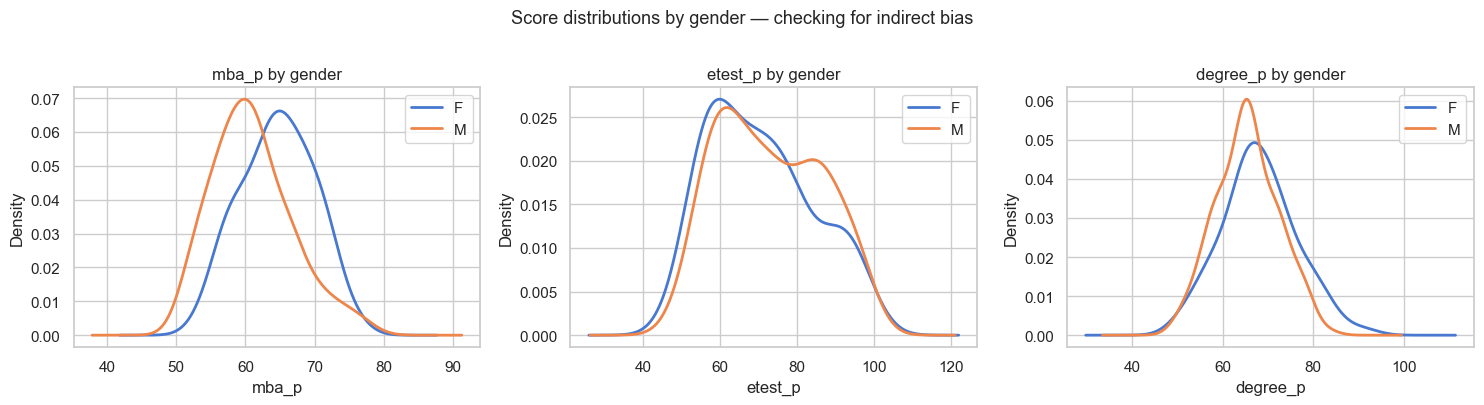

In [17]:
# Score distributions by gender 
score_cols = ['mba_p', 'etest_p', 'degree_p']

fig, axes = plt.subplots(1, len(score_cols), figsize=(5 * len(score_cols), 4))

for i, col in enumerate(score_cols):
    for gender, grp in df.groupby('gender'):
        grp[col].plot(kind='kde', ax=axes[i], label=gender, linewidth=2)
    axes[i].set_title(f'{col} by gender', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].legend()

fig.suptitle('Score distributions by gender — checking for indirect bias', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

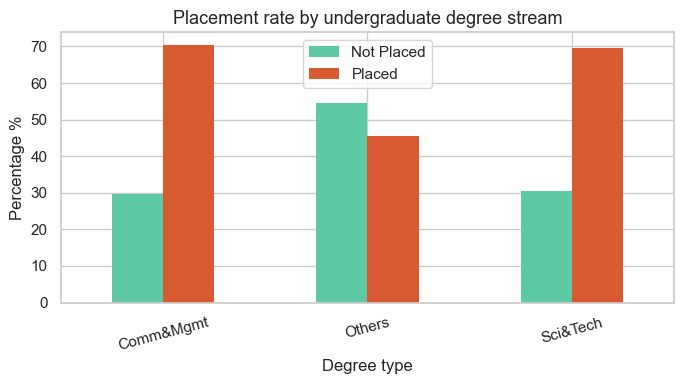

A model that uses degree_t may reproduce class-based bias even if that is not intended.


In [18]:
# Degree stream as a socioeconomic proxy
degree_bias = df.groupby('degree_t')[TARGET].value_counts(normalize=True)\
                .mul(100).unstack().fillna(0)

fig, ax = plt.subplots(figsize=(7, 4))
degree_bias.plot(kind='bar', ax=ax, color=['#5DCAA5', '#D85A30'], edgecolor='none')
ax.set_title('Placement rate by undergraduate degree stream', fontsize=13)
ax.set_ylabel('Percentage %')
ax.set_xlabel('Degree type')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='')
plt.tight_layout()
plt.show()

print('A model that uses degree_t may reproduce class-based bias even if that is not intended.')

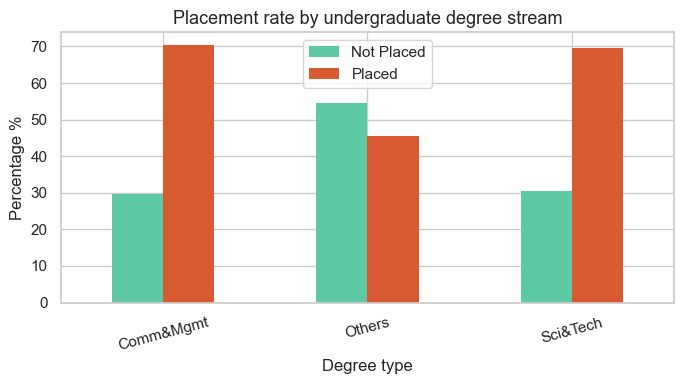

A model that uses degree_t may reproduce class-based bias even if that is not intended.


In [19]:
# Degree stream as a socioeconomic proxy
degree_bias = df.groupby('degree_t')[TARGET].value_counts(normalize=True)\
                .mul(100).unstack().fillna(0)

fig, ax = plt.subplots(figsize=(7, 4))
degree_bias.plot(kind='bar', ax=ax, color=['#5DCAA5', '#D85A30'], edgecolor='none')
ax.set_title('Placement rate by undergraduate degree stream', fontsize=13)
ax.set_ylabel('Percentage %')
ax.set_xlabel('Degree type')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='')
plt.tight_layout()
plt.show()

print('A model that uses degree_t may reproduce class-based bias even if that is not intended.')

In many educational systems, the degree subject a student studies correlates with the school and socioeconomic background they came from So placing degree_t in our model may therefore encode class, not just academic merit.

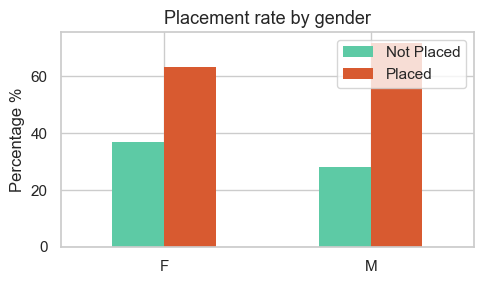

In [20]:
# Placement rate by gender
fig, ax = plt.subplots(figsize=(5, 3))
gender_placement = df.groupby('gender')[TARGET].value_counts(normalize=True).mul(100).unstack()
gender_placement.plot(kind='bar', ax=ax, color=['#5DCAA5', '#D85A30'], edgecolor='none')
ax.set_title('Placement rate by gender', fontsize=13)
ax.set_ylabel('Percentage %')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.show()

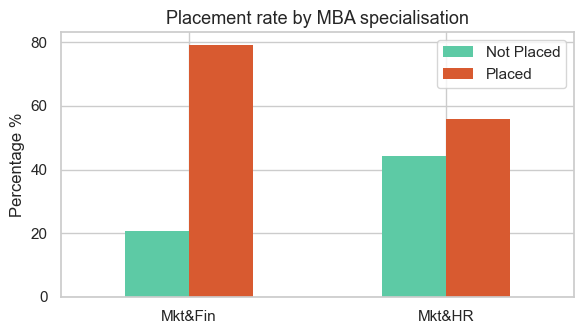

In [21]:
# Placement rate by degree specialisation
fig, ax = plt.subplots(figsize=(6, 3.5))
spec_placement = df.groupby('specialisation')[TARGET].value_counts(normalize=True).mul(100).unstack()
spec_placement.plot(kind='bar', ax=ax, color=['#5DCAA5', '#D85A30'], edgecolor='none')
ax.set_title('Placement rate by MBA specialisation', fontsize=13)
ax.set_ylabel('Percentage %')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.show()

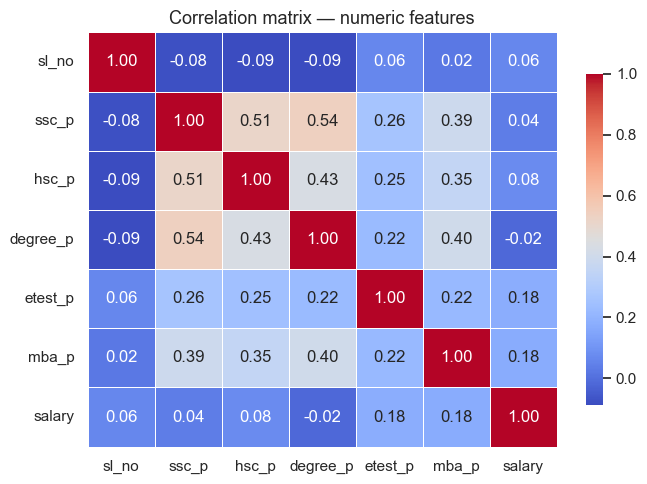

In [22]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include='number').columns.tolist()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation matrix — numeric features', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Initial observations

**Data quality**

The dataset contains 215 rows and 15 columns, comprising 7 numeric and 8 categorical features. The only missing values are in the salary column, which has 67 missing entries (31.16%). This is structurally expected rather than an error in the data quality: salary is only recorded for students who were successfully placed, meaning it is a consequence of the target variable, not a predictor of it. `salary` will therefore be dropped entirely before modelling to prevent target leakage. No other columns contain missing values.

Outliers:
- `hsc_p` (higher secondary score) contains 8 outliers identified by the IQR method, ranging from 37.0 to 97.7. These could reflect genuine variation in student academic background rather than data entry errors and will be retained. 

- `degree_p` has one high outlier at 91.0, also plausibly legitimate, and no other numeric feature contains outliers.

**Class balance**
The target variable status is moderately imbalanced as 148 students were placed (68.8%) versus 67 not placed (31.2%), giving a class ratio of 2.21:1. The auto-imbalance check flagged this, and it has a direct consequence for evaluation. Accuracy alone could be a misleading metric, since a model predicting "Placed" for every student would achieve ~69% accuracy without learning anything. Weighted F1-score and the precision/recall breakdown for the minority class (Not Placed) will therefore be prioritised as primary evaluation metrics, alongside a stratified train/test split to preserve this ratio.

**Feature-target relationships**

From the KDE distributions and boxplots, the most discriminative numeric features are `ssc_p` and `hsc_p` (secondary and higher secondary scores respectively). Placed students have a mean `ssc_p` of 71.72 versus 57.54 for unplaced students, and a mean `hsc_p` of 69.93 versus 58.40: gaps of roughly 14 percentage points each. 

`degree_p` shows a smaller but still meaningful gap (68.74 placed vs 61.13 not placed). By contrast, `mba_p` shows almost no separation (62.58 vs 61.61), suggesting MBA score alone is a weak predictor of placement outcome. `etest_p` shows moderate separation (73.24 vs 69.59).

Among categorical features, MBA specialisation shows the largest gap: students who specialised in Mkt&Fin were placed at a rate of 79.2%, compared to 55.8% for Mkt&HR with a difference of over 23 percentage points. Work experience is the strongest categorical predictor overall. Students with prior work experience were placed at 86.5% versus 59.6% for those without.

**Multicollinearity**

No feature pair exceeds the r = 0.7 threshold for high multicollinearity. The strongest correlations are between `ssc_p` and `degree_p` (r = 0.54) and between `ssc_p` and `hsc_p` (r = 0.51), which is intuitive as students who perform well in secondary school tend to perform consistently across subsequent academic stages. These mid-range correlations do not pose a multicollinearity problem for tree-based models, though they are worth noting for any distance-based or linear approaches.

**Bias vectors identified**
Gender correlates meaningfully with placement rate. Male students were placed at 71.9% versus 63.2% for female students and an 8.7 percentage point gap  is substantively significant even if the dataset is too small for formal significance testing. In a real recruitment pipeline operating at scale, an 8.7pp disparity would translate to systematically fewer female candidates progressing at every stage. The gender-by-workex breakdown adds further nuance as female students with work experience were placed at 81.8%, exceeding male students without experience (62.1%) suggesting that work experience is a confounding variable. However, this does not eliminate the gender gap, it reframes it. Female students in this dataset are underrepresented in work experience (only 22% of female students had work experience versus 36% of male students), which is itself a structural disparity.

On score distributions by gender, female students actually outperform male students on mean `mba_p` (64.64 vs 60.98) and `degree_p` (68.09 vs 65.43), while male students score slightly higher on `etest_p` (72.93 vs 70.59). The fact that female students score higher academically yet are placed less frequently is a notable trend where, as a result, the gap in placement rates cannot be directly attributed to academic performance. This raises the possibility that the model will learn to use gender as an indirect negative predictor.

Undergraduate degree stream also warrants further consideration as a potential socioeconomic proxy for the model. Students from the "Others" degree category which is a heterogeneous group, likely including humanities and arts subjects, were placed at only 45.5%, compared to 70.3% for Commerce & Management and 69.5% for Science & Technology. In many educational systems, subject choice at undergraduate level correlates with school type and socioeconomic background, meaning `degree_t` may encode class position rather than, or in addition to, academic aptitude. Including it in the model risks reproducing structural disadvantage and this will be noted in the model evaluation write-up.